# Phân Tích GDP, Thất Nghiệp & Lạm Phát tại Việt Nam (2000–2024)
### Kiểm định Okun's Law, Phillips Curve & Mô hình Hồi quy Kinh tế Vĩ mô

**Thành viên:** Khang  
**Phần:** GDP, Unemployment & Inflation Analysis  
**Dữ liệu:** World Bank + Our World in Data | Giai đoạn: 2000–2024

---
**Mục lục:**
1. Cài đặt & Tải dữ liệu
2. Thống kê mô tả & EDA
3. Phân tích xu hướng theo thời gian
4. Phân tích tương quan (Heatmap)
5. Kiểm định Okun's Law (GDP ↔ Thất nghiệp)
6. Kiểm định Phillips Curve (Lạm phát ↔ Thất nghiệp)
7. Mô hình hồi quy đa biến
8. Tổng hợp & Kết luận kinh tế


## 1. Cài đặt thư viện & Tải dữ liệu

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import r2_score

# ── Style toàn cục ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

C_BLUE   = '#2166ac'
C_RED    = '#d62728'
C_ORANGE = '#e6820a'
C_GREEN  = '#2ca02c'
C_GRAY   = '#7f7f7f'
C_COVID  = '#fee0d2'   # vùng COVID

print("✅ Thư viện đã sẵn sàng.")


✅ Thư viện đã sẵn sàng.


In [2]:
# ── Tải dữ liệu ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv('../../data/processed/merged_dataset.csv')

# Lọc giai đoạn phân tích: 2000–2024
df = df_raw[(df_raw['year'] >= 2000) & (df_raw['year'] <= 2024)].copy().reset_index(drop=True)

# Các biến phân tích chính
COLS = ['year', 'gdp_growth', 'unemployment', 'inflation_cpi',
        'exports_percent_gdp', 'fdi_percent_gdp', 'stringency_index']

df = df[COLS].copy()
df['stringency_index'] = df['stringency_index'].fillna(0)

print(f"Shape: {df.shape}  |  Giai đoạn: {int(df['year'].min())}–{int(df['year'].max())}")
print()
print(df.to_string(index=False))


Shape: (25, 7)  |  Giai đoạn: 2000–2024

 year  gdp_growth  unemployment  inflation_cpi  exports_percent_gdp  fdi_percent_gdp  stringency_index
 2000    6.787316         2.260      -1.710337            53.921497         4.163924          0.000000
 2001    6.192893         2.760      -0.431545            55.061933         3.977335          0.000000
 2002    6.320821         2.120       3.830828            54.739134         3.992687          0.000000
 2003    6.899063         2.250       3.234648            56.673258         3.666012          0.000000
 2004    7.536411         2.140       7.754947            59.731041         3.544081          0.000000
 2005    7.547248         2.078       8.284572            63.699493         3.390404          0.000000
 2006    6.977955         2.046       7.418017            67.716814         3.616001          0.000000
 2007    7.129504         2.026       8.344449            70.517875         8.654718          0.000000
 2008    5.661771         1.889 

## 2. Thống kê mô tả & EDA

Trước khi phân tích, ta cần nắm rõ phân phối và đặc trưng của từng biến.


In [3]:
# ── Thống kê mô tả ──────────────────────────────────────────────────────────
desc = df.drop(columns='year').describe().T
desc.columns = ['Count','Mean','Std','Min','25%','Median','75%','Max']
desc = desc.round(3)
print("=== Thống kê mô tả – Việt Nam 2000–2024 ===\n")
print(desc.to_string())


=== Thống kê mô tả – Việt Nam 2000–2024 ===

                     Count    Mean     Std     Min     25%  Median     75%     Max
gdp_growth            25.0   6.333   1.350   2.554   5.662   6.690   7.091   8.538
unemployment          25.0   1.789   0.455   0.999   1.570   1.848   2.103   2.760
inflation_cpi         25.0   5.698   5.453  -1.710   3.157   3.621   7.755  23.115
exports_percent_gdp   25.0  71.075  12.995  53.921  61.180  69.599  84.382  93.850
fdi_percent_gdp       25.0   4.811   1.520   3.390   3.993   4.278   4.932   9.663
stringency_index      25.0   6.587  18.799   0.000   0.000   0.000   0.000  69.148


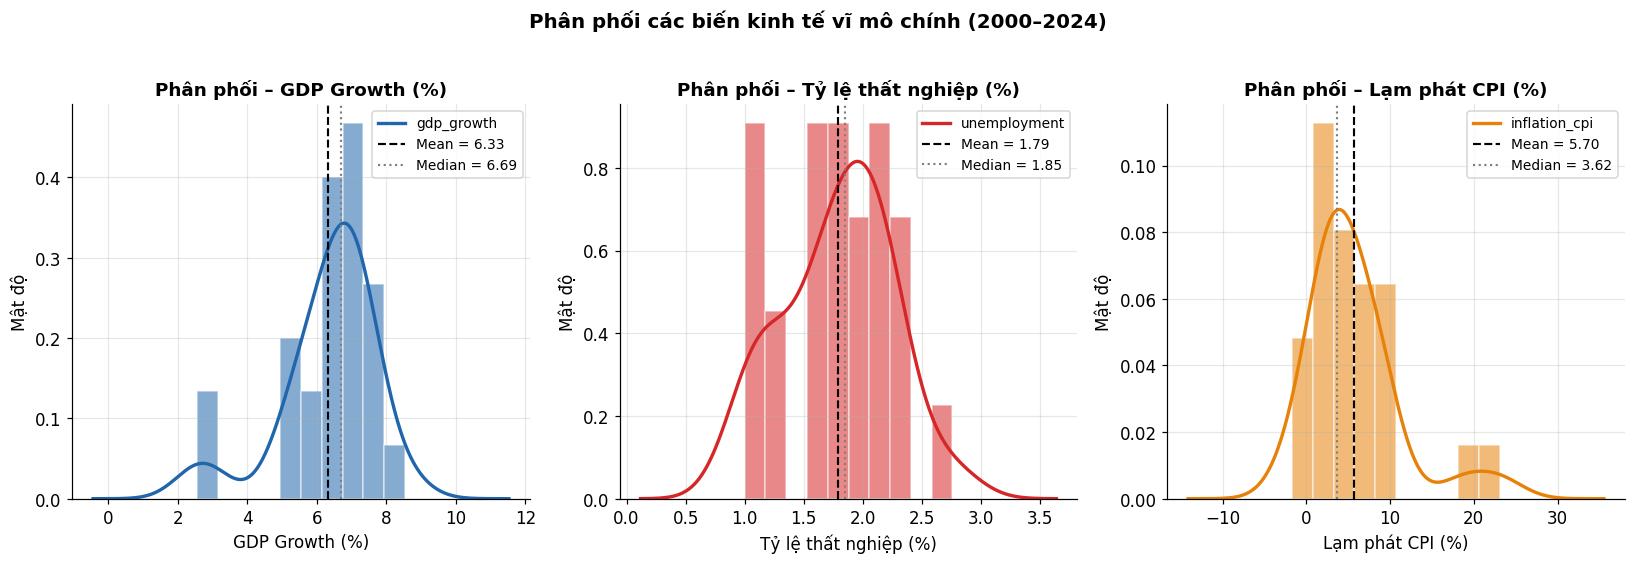

In [4]:
# ── Phân phối từng biến (histogram + KDE) ───────────────────────────────────
ana_cols = [
    ('gdp_growth',    'GDP Growth (%)',         C_BLUE),
    ('unemployment',  'Tỷ lệ thất nghiệp (%)',  C_RED),
    ('inflation_cpi', 'Lạm phát CPI (%)',        C_ORANGE),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label, color) in zip(axes, ana_cols):
    ax.hist(df[col], bins=10, color=color, alpha=0.55, edgecolor='white', density=True)
    df[col].plot.kde(ax=ax, color=color, linewidth=2.2)
    ax.axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.4, label=f'Mean = {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color=C_GRAY,   linestyle=':',  linewidth=1.4, label=f'Median = {df[col].median():.2f}')
    ax.set_title(f'Phân phối – {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Mật độ')
    ax.legend(fontsize=9)

plt.suptitle('Phân phối các biến kinh tế vĩ mô chính (2000–2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_distributions.png', bbox_inches='tight')
plt.show()


### Nhận xét phân phối

| Biến | Đặc điểm phân phối |
|------|-------------------|
| **GDP Growth** | Phân phối lệch trái — phần lớn các năm tăng trưởng 5–8%, trung bình 6.33%, nhưng có 2 năm thấp bất thường (2020: 2.87%, 2021: 2.55%) kéo đuôi trái. |
| **Thất nghiệp** | Phân phối tương đối đối xứng, trung bình 1.79%, dao động từ 0.999% (2011) đến 2.76% (2001). Không có bimodal rõ ràng — giai đoạn COVID chỉ tạo ra 2 điểm ngoại lệ, không đủ để hình thành đỉnh riêng. |
| **Lạm phát CPI** | Phân phối lệch phải mạnh — phần lớn năm có lạm phát 0.6–9%, trung bình 5.70%, nhưng 2 outlier rõ ràng là 2008 (23.12%) và 2011 (18.68%). |


## 3. Phân tích xu hướng theo thời gian

Quan sát diễn biến lịch sử của GDP Growth, Thất nghiệp và Lạm phát để hiểu bối cảnh.


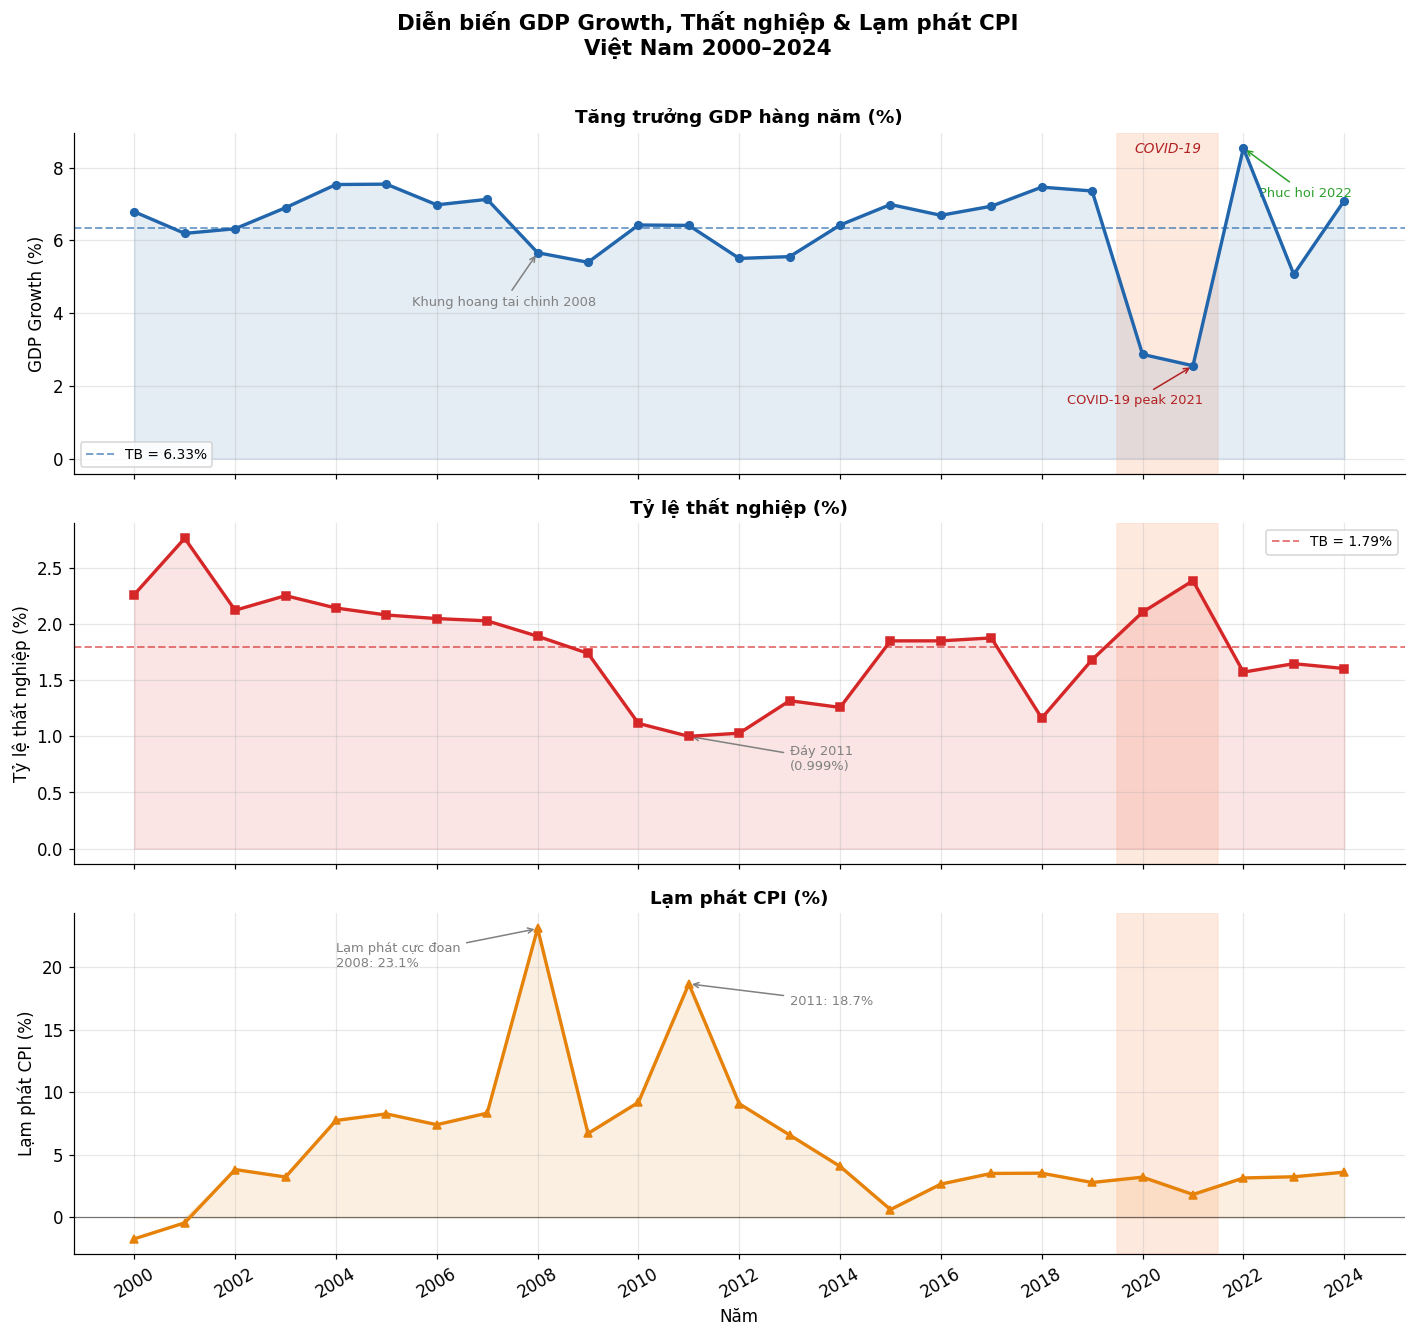

In [5]:
# ── Hàm tiện ích vẽ vùng COVID ──────────────────────────────────────────────
def add_covid_band(ax, label=True):
    ax.axvspan(2019.5, 2021.5, color=C_COVID, alpha=0.7, zorder=0)
    if label:
        ax.text(2020.5, ax.get_ylim()[1]*0.97, 'COVID-19',
                ha='center', va='top', fontsize=9, color='firebrick', style='italic')

# ── Plot 3 panels ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

# GDP Growth
ax = axes[0]
ax.plot(df['year'], df['gdp_growth'], color=C_BLUE, linewidth=2.2, marker='o', markersize=5, zorder=5)
ax.fill_between(df['year'], df['gdp_growth'], alpha=0.12, color=C_BLUE)
ax.axhline(df['gdp_growth'].mean(), color=C_BLUE, linestyle='--', alpha=0.6, linewidth=1.3,
           label=f'TB = {df["gdp_growth"].mean():.2f}%')
ax.set_ylabel('GDP Growth (%)')
ax.set_title('Tăng trưởng GDP hàng năm (%)', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
# Annotate key events
ax.annotate('Khung hoang tai chinh 2008', xy=(2008, 5.66), xytext=(2005.5, 4.2),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8.5, color='gray')
ax.annotate('COVID-19 peak 2021', xy=(2021, 2.55), xytext=(2018.5, 1.5),
            arrowprops=dict(arrowstyle='->', color='firebrick'), fontsize=8.5, color='firebrick')
ax.annotate('Phuc hoi 2022', xy=(2022, 8.54), xytext=(2022.3, 7.2),
            arrowprops=dict(arrowstyle='->', color=C_GREEN), fontsize=8.5, color=C_GREEN)
add_covid_band(ax)

# Unemployment
ax = axes[1]
ax.plot(df['year'], df['unemployment'], color=C_RED, linewidth=2.2, marker='s', markersize=5, zorder=5)
ax.fill_between(df['year'], df['unemployment'], alpha=0.12, color=C_RED)
ax.axhline(df['unemployment'].mean(), color=C_RED, linestyle='--', alpha=0.6, linewidth=1.3,
           label=f'TB = {df["unemployment"].mean():.2f}%')
ax.set_ylabel('Tỷ lệ thất nghiệp (%)')
ax.set_title('Tỷ lệ thất nghiệp (%)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.annotate('Đáy 2011\n(0.999%)', xy=(2011, 0.999), xytext=(2013, 0.7),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8.5, color='gray')
add_covid_band(ax, label=False)

# Inflation
ax = axes[2]
ax.plot(df['year'], df['inflation_cpi'], color=C_ORANGE, linewidth=2.2, marker='^', markersize=5, zorder=5)
ax.fill_between(df['year'], df['inflation_cpi'].clip(lower=0), alpha=0.12, color=C_ORANGE)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Lạm phát CPI (%)')
ax.set_title('Lạm phát CPI (%)', fontweight='bold')
ax.set_xlabel('Năm')
ax.annotate('Lạm phát cực đoan\n2008: 23.1%', xy=(2008, 23.1), xytext=(2004, 20),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8.5, color='gray')
ax.annotate('2011: 18.7%', xy=(2011, 18.68), xytext=(2013, 17),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8.5, color='gray')
add_covid_band(ax, label=False)

plt.xticks(df['year'][::2], rotation=30)
plt.suptitle('Diễn biến GDP Growth, Thất nghiệp & Lạm phát CPI\nViệt Nam 2000–2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_trends.png', bbox_inches='tight')
plt.show()


### Nhận xét xu hướng

**GDP Growth (Tăng trưởng GDP):**
- Duy trì ổn định ở mức 5.4–9.5% trong 2000–2019, phản ánh thời kỳ tăng trưởng cao nhờ cải cách Đổi Mới, gia nhập WTO (2007) và thu hút FDI.
- 2020–2021: Giảm mạnh còn 2.87% và 2.55% — tác động trực tiếp của COVID-19 làm đứt gãy chuỗi cung ứng, đóng cửa nhà máy và thu hẹp thương mại quốc tế.
- 2022: Phục hồi nhanh lên 8.54% — mức cao nhất trong 25 năm — nhờ mở cửa trở lại và cầu bị dồn nén.

**Tỷ lệ thất nghiệp:**
- Xu hướng dài hạn giảm: từ 2.76% (2001) xuống đáy 0.999% (2011), phản ánh quá trình công nghiệp hóa và hút dòng lao động từ nông nghiệp sang công nghiệp – dịch vụ.
- Biến động trong 2012–2019 ở mức 1.0–2.3% khi cơ cấu lao động tiếp tục điều chỉnh.
- COVID-19: Tăng lên 2.10% (2020) và 2.38% (2021) nhưng không tăng đột biến như các nước phát triển — một đặc thù của thị trường lao động phi chính thức Việt Nam.

**Lạm phát CPI:**
- Việt Nam Chính thức tham gia vào Tổ chức thương mại quốc tế vào ngày 11/1/2007, khi này các nguồn vốn FDI chảy vào nền kinh tế một các bùng nổ, tuy nhiên các nguồn vốn này chưa tạo ra giá trị hàng hóa ngay lập tức nên dẫn đến bùng nổ lạm phát
- Sau 2012: NHNN kiểm soát hiệu quả, lạm phát ổn định ở 0.6–9%, phần lớn dưới 4%.
- 2020–2021: Lạm phát thấp (3.22% và 1.83%) dù chính phủ bơm tiền — do cầu tiêu dùng suy yếu vì giãn cách xã hội.


## 4. Phân tích tương quan (Correlation Heatmap)

Tính hệ số tương quan Pearson (tuyến tính) và Spearman (phi tham số, robust hơn với outlier).


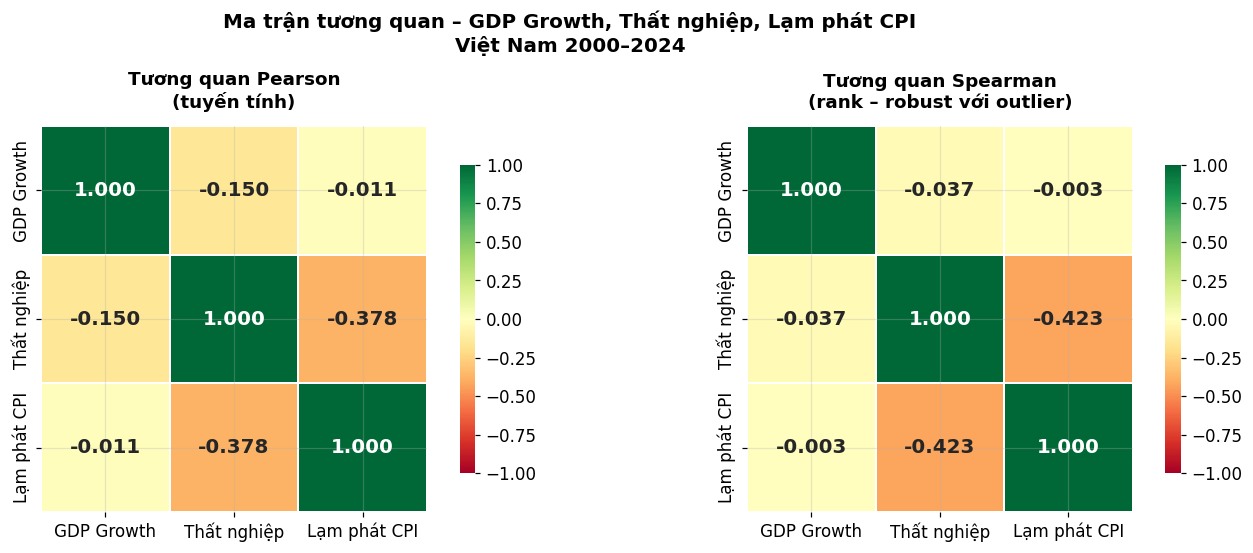

In [6]:
ana_vars = ['gdp_growth', 'unemployment', 'inflation_cpi']
labels   = ['GDP Growth', 'Thất nghiệp', 'Lạm phát CPI']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, method, title in zip(axes, ['pearson', 'spearman'],
                              ['Tương quan Pearson\n(tuyến tính)',
                               'Tương quan Spearman\n(rank – robust với outlier)']):
    mat = df[ana_vars].rename(columns=dict(zip(ana_vars, labels))).corr(method=method)
    mask = np.zeros_like(mat, dtype=bool)
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, ax=ax, square=True, linewidths=1,
                annot_kws={'size': 13, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold', pad=12)
    ax.tick_params(labelsize=11)

plt.suptitle('Ma trận tương quan – GDP Growth, Thất nghiệp, Lạm phát CPI\nViệt Nam 2000–2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_correlation_heatmap.png', bbox_inches='tight')
plt.show()


In [7]:
# ── Kiểm định ý nghĩa thống kê ──────────────────────────────────────────────
print("=== Kiểm định ý nghĩa thống kê tương quan (Pearson) ===\n")
pairs = [
    ('gdp_growth',    'unemployment',  'GDP Growth  ↔  Thất nghiệp'),
    ('gdp_growth',    'inflation_cpi', 'GDP Growth  ↔  Lạm phát CPI'),
    ('inflation_cpi', 'unemployment',  'Lạm phát CPI  ↔  Thất nghiệp'),
]
for x, y, name in pairs:
    r, p = pearsonr(df[x], df[y])
    rs, ps = spearmanr(df[x], df[y])
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else 'không ý nghĩa'))
    print(f"{name}")
    print(f"  Pearson  r = {r:+.3f}  (p = {p:.4f}) {sig}")
    print(f"  Spearman ρ = {rs:+.3f}  (p = {ps:.4f})")
    print()
print("Ghi chú: * p<0.1   ** p<0.05   *** p<0.01")


=== Kiểm định ý nghĩa thống kê tương quan (Pearson) ===

GDP Growth  ↔  Thất nghiệp
  Pearson  r = -0.150  (p = 0.4740) không ý nghĩa
  Spearman ρ = -0.037  (p = 0.8623)

GDP Growth  ↔  Lạm phát CPI
  Pearson  r = -0.011  (p = 0.9569) không ý nghĩa
  Spearman ρ = -0.003  (p = 0.9884)

Lạm phát CPI  ↔  Thất nghiệp
  Pearson  r = -0.378  (p = 0.0625) *
  Spearman ρ = -0.423  (p = 0.0351)

Ghi chú: * p<0.1   ** p<0.05   *** p<0.01


### Nhận xét tương quan

| Cặp biến | Pearson r | Spearman ρ | Ý nghĩa |
|----------|-----------|------------|---------|
| GDP Growth ↔ Thất nghiệp | -0.150 (p=0.474) | -0.037 (p=0.862) | Không có ý nghĩa thống kê — quan hệ âm nhưng yếu và không đáng tin cậy với mẫu này |
| GDP Growth ↔ Lạm phát CPI | -0.011 (p=0.957) | -0.003 (p=0.988) | Gần như không có tương quan tuyến tính — 2 biến không đồng biến hay nghịch biến rõ ràng |
| Lạm phát CPI ↔ Thất nghiệp | -0.378 (p=0.063) | -0.423 (p=0.035) | Âm, có ý nghĩa ở mức 10% (Pearson) và 5% (Spearman) — tương quan âm nhất quán |

Cả hai hệ số Pearson và Spearman của cặp Lạm phát CPI ↔ Thất nghiệp đều âm, trái ngược với kỳ vọng từ Phillips Curve truyền thống (nghịch chiều lạm phát–thất nghiệp là đúng). Điều này phản ánh rằng ở Việt Nam, giai đoạn lạm phát cao (2004–2012) trùng với giai đoạn thất nghiệp giảm mạnh, còn giai đoạn lạm phát thấp sau 2012 lại có thất nghiệp dao động không nhất quán.

Lưu ý: Spearman robust hơn với outlier 2008, 2011. Kết quả Spearman âm hơn Pearson xác nhận quan hệ âm này không phải do outlier tạo ra mà là xu hướng thực trong dữ liệu.


## 5. Kiểm định Okun's Law

**Lý thuyết:** Okun's Law (Arthur Okun, 1962) mô tả quan hệ kinh nghiệm:  
Mỗi khi GDP tăng trưởng tăng thêm 1 điểm % → tỷ lệ thất nghiệp thay đổi một lượng tương ứng.

**Dạng kiểm định sử dụng – Difference:**

$$\Delta u_t = \alpha + \beta \cdot g_t + \varepsilon_t$$

Trong đó $\Delta u_t = u_t - u_{t-1}$ là thay đổi tỷ lệ thất nghiệp, $g_t$ là tốc độ tăng trưởng GDP năm $t$.  
$\beta < 0$ xác nhận Okun's Law tồn tại: GDP tăng trưởng cao → thất nghiệp giảm.

Dạng Difference được ưu tiên so với dạng Level vì sử dụng biến động thay vì mức, tránh vấn đề non-stationarity của chuỗi tỷ lệ thất nghiệp.


In [8]:
# ── Chuẩn bị biến sai phân ───────────────────────────────────────────────────
df['delta_u'] = df['unemployment'].diff()      # Δ thất nghiệp
df_ok = df.dropna(subset=['delta_u', 'gdp_growth']).copy()

# ── Mô hình DIFFERENCE ───────────────────────────────────────────────────────
X1 = sm.add_constant(df_ok['gdp_growth'])
m1 = sm.OLS(df_ok['delta_u'], X1).fit()

print("══════════════════════════════════════════════════")
print("  OKUN'S LAW – DẠNG DIFFERENCE")
print("  Phương trình: Δu = α + β·GDP_Growth + ε")
print("══════════════════════════════════════════════════")
print(f"  α (const)     = {m1.params['const']:+.4f}  (p = {m1.pvalues['const']:.4f})")
print(f"  β (gdp_growth) = {m1.params['gdp_growth']:+.4f}  (p = {m1.pvalues['gdp_growth']:.4f})")
print(f"  R²            = {m1.rsquared:.4f}")
print(f"  R²adj         = {m1.rsquared_adj:.4f}")
print(f"  n             = {int(m1.nobs)}")
print(f"  F-stat p      = {m1.f_pvalue:.4f}")


══════════════════════════════════════════════════
  OKUN'S LAW – DẠNG DIFFERENCE
  Phương trình: Δu = α + β·GDP_Growth + ε
══════════════════════════════════════════════════
  α (const)     = +0.6456  (p = 0.0762)
  β (gdp_growth) = -0.1066  (p = 0.0599)
  R²            = 0.1517
  R²adj         = 0.1132
  n             = 24
  F-stat p      = 0.0599


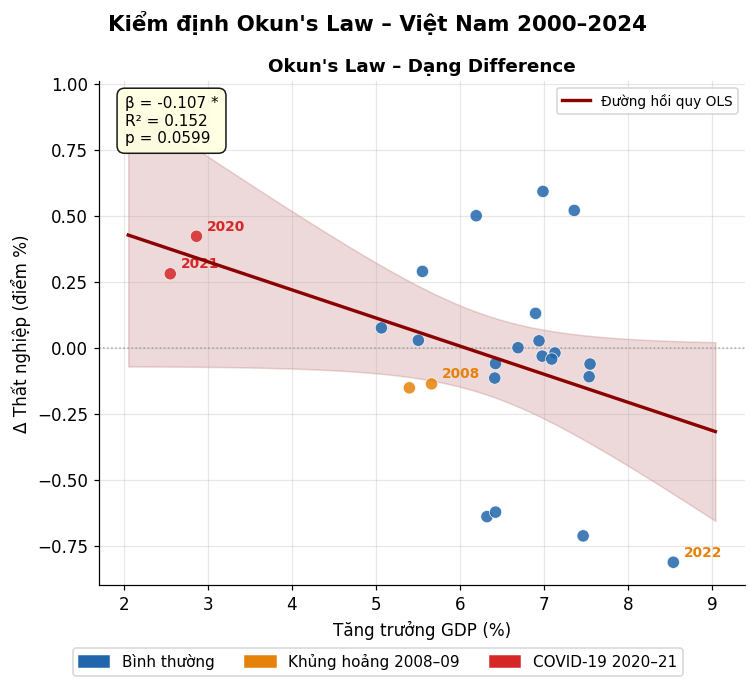

In [9]:
# ── Scatter + regression line ────────────────────────────────────────────────

# Chỉ giữ lại Okun's Law dạng Difference

fig, ax = plt.subplots(figsize=(7, 6))



# Cấu hình cho dạng Difference

data, xcol, ycol, model, title, xlabel, ylabel = (df_ok, 'gdp_growth', 'delta_u', m1,
     "Okun's Law – Dạng Difference",
     'Tăng trưởng GDP (%)', 'Δ Thất nghiệp (điểm %)')

# Màu điểm theo giai đoạn

colors = [C_RED if y in [2020,2021] else

          C_ORANGE if y in [2008,2009] else C_BLUE

          for y in data['year']]



ax.scatter(data[xcol], data[ycol], c=colors, s=65, zorder=5, alpha=0.85, edgecolors='white', linewidth=0.5)



# Đường hồi quy

xr = np.linspace(data[xcol].min()-0.5, data[xcol].max()+0.5, 200)

yr = model.params['const'] + model.params['gdp_growth'] * xr

ax.plot(xr, yr, '-', color='darkred', linewidth=2.2, zorder=6, label='Đường hồi quy OLS')



# CI 95%

pred = model.get_prediction(sm.add_constant(pd.Series(xr, name='gdp_growth')))
ci = pred.summary_frame(alpha=0.05)
ax.fill_between(xr, ci['mean_ci_lower'], ci['mean_ci_upper'], alpha=0.15, color='darkred')


# Nhãn năm đặc biệt
for _, row in data[data['year'].isin([2020,2021,2008,2022])].iterrows():
    ax.annotate(str(int(row['year'])),
                (row[xcol], row[ycol]),
                textcoords='offset points', xytext=(7, 4),
                fontsize=9, fontweight='bold',
                color=C_RED if row['year'] in [2020,2021] else C_ORANGE)


ax.axhline(0, color=C_GRAY, linestyle=':', alpha=0.6, linewidth=1)
ax.set_title(title, fontweight='bold')
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.legend(fontsize=9)


# Thống kê box
beta = model.params['gdp_growth']
pval = model.pvalues['gdp_growth']
r2   = model.rsquared
sig  = '***' if pval<0.01 else ('**' if pval<0.05 else ('*' if pval<0.1 else 'n.s.'))
ax.text(0.04, 0.97,
        f'β = {beta:.3f} {sig}\nR² = {r2:.3f}\np = {pval:.4f}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))


# Legend màu
patches = [mpatches.Patch(color=C_BLUE,   label='Bình thường'),
           mpatches.Patch(color=C_ORANGE,  label='Khủng hoảng 2008–09'),
           mpatches.Patch(color=C_RED,     label='COVID-19 2020–21')]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))


plt.suptitle("Kiểm định Okun's Law – Việt Nam 2000–2024",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_okuns_law.png', bbox_inches='tight')
plt.show()


In [10]:
# ── So sánh Okun trước và sau khi loại COVID ─────────────────────────────────
df_pre  = df[~df['year'].isin([2020,2021])].dropna(subset=['delta_u','gdp_growth'])
df_ok_pre = df_pre.copy()

X_pre = sm.add_constant(df_ok_pre['gdp_growth'])
m_pre = sm.OLS(df_ok_pre['delta_u'], X_pre).fit()

print("=== So sánh hệ số β Okun's Law ===\n")
print(f"{'Mẫu đầy đủ (2000–2024)':<30} β = {m1.params['gdp_growth']:+.4f}  R² = {m1.rsquared:.3f}  p = {m1.pvalues['gdp_growth']:.4f}")
print(f"{'Loại COVID (2020–2021)':<30} β = {m_pre.params['gdp_growth']:+.4f}  R² = {m_pre.rsquared:.3f}  p = {m_pre.pvalues['gdp_growth']:.4f}")
print()
print("Nhận xét: COVID-19 là điểm ngoại lệ cấu trúc – GDP giảm mạnh nhưng")
print("thất nghiệp không tăng tương ứng do đặc thù thị trường lao động phi chính thức.")


=== So sánh hệ số β Okun's Law ===

Mẫu đầy đủ (2000–2024)         β = -0.1066  R² = 0.152  p = 0.0599
Loại COVID (2020–2021)         β = -0.1114  R² = 0.064  p = 0.2560

Nhận xét: COVID-19 là điểm ngoại lệ cấu trúc – GDP giảm mạnh nhưng
thất nghiệp không tăng tương ứng do đặc thù thị trường lao động phi chính thức.


### Kết luận Okun's Law

**Kết quả kiểm định:**

| Dạng mô hình | β | R² | p-value | Ý nghĩa thống kê |
|---|---|---|---|---|
| Difference: Δu ~ GDP Growth (toàn mẫu) | -0,107 | 0,152 | 0,060 | Có ý nghĩa ở mức 10% (*) |
| Difference: Loại COVID 2020–2021 | -0,111 | 0,064 | 0,256 | Không có ý nghĩa |

**Giải thích kinh tế:**

Okun's Law tồn tại yếu tại Việt Nam — dạng Difference cho thấy β âm (-0,107) có ý nghĩa biên ở mức 10%, nghĩa là mỗi 1 điểm % tăng trưởng GDP thêm tương ứng với thất nghiệp thay đổi khoảng -0,107 điểm %. Quan hệ này không ổn định qua các mẫu con.

Khi loại COVID, hệ số β còn yếu hơn và không còn ý nghĩa (p=0,256), cho thấy COVID-19 đóng góp vào tín hiệu âm của mô hình toàn mẫu — 2 năm GDP giảm mạnh kết hợp thất nghiệp tăng nhẹ tạo ra các điểm dữ liệu ủng hộ Okun's Law.

Okun's Coefficient ước tính ~0,1 điểm %/điểm % GDP — nhỏ hơn đáng kể so với hệ số ~0,4–0,5 ở Mỹ và ~0,3–0,4 ở EU, do đặc thù thị trường lao động phi chính thức chiếm tỷ trọng lớn và vai trò đệm đỡ của khu vực nông nghiệp tại Việt Nam.


## 6. Kiểm định Phillips Curve

**Lý thuyết:** Phillips Curve (A.W. Phillips, 1958) mô tả quan hệ nghịch chiều giữa lạm phát và thất nghiệp:
$$\pi_t = \alpha + \beta \cdot u_t + \varepsilon_t, \quad \beta < 0$$

Khi thất nghiệp thấp → sức ép tiền lương tăng → doanh nghiệp tăng giá → lạm phát cao hơn.

**Ta kiểm định 3 phiên bản:**
1. Toàn mẫu (2000–2024)
2. Loại outlier lạm phát (loại 2008, 2011)
3. Theo giai đoạn: trước và sau 2012 (khi NHNN kiểm soát lạm phát tốt hơn)


In [11]:
# ── Mô hình 1: Toàn mẫu ─────────────────────────────────────────────────────
X_all = sm.add_constant(df['unemployment'])
m_all = sm.OLS(df['inflation_cpi'], X_all).fit()

# ── Mô hình 2: Loại outlier 2008, 2011 ──────────────────────────────────────
df_clean = df[~df['year'].isin([2008, 2011])].copy()
X_cl  = sm.add_constant(df_clean['unemployment'])
m_cl  = sm.OLS(df_clean['inflation_cpi'], X_cl).fit()

# ── Mô hình 3a: Trước 2012 (high-inflation era) ──────────────────────────────
df_pre12 = df[df['year'] < 2012].copy()
X_pre12 = sm.add_constant(df_pre12['unemployment'])
m_pre12 = sm.OLS(df_pre12['inflation_cpi'], X_pre12).fit()

# ── Mô hình 3b: Từ 2012 trở đi (low-inflation era) ──────────────────────────
df_post12 = df[df['year'] >= 2012].copy()
X_post12 = sm.add_constant(df_post12['unemployment'])
m_post12 = sm.OLS(df_post12['inflation_cpi'], X_post12).fit()

print("=== Bảng tóm tắt hệ số β Phillips Curve ===\n")
print(f"{'Mẫu':<35} {'β':>8}  {'p-value':>9}  {'R²':>7}  {'Kết luận'}")
print("-"*75)
for name, m in [
    ('Toàn mẫu (2000–2024)',        m_all),
    ('Loại outlier 2008,2011',       m_cl),
    ('Trước 2012 (lạm phát cao)',    m_pre12),
    ('Từ 2012 (lạm phát kiểm soát)', m_post12),
]:
    b = m.params['unemployment']
    p = m.pvalues['unemployment']
    r = m.rsquared
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else 'n.s.'))
    kq  = '✅ Hỗ trợ' if b < 0 and p < 0.1 else ('⚠️ Ngược chiều' if b>0 else '❌ Không ý nghĩa')
    print(f"{name:<35} {b:>+8.3f}  {p:>9.4f}  {r:>7.3f}  {kq} {sig}")


=== Bảng tóm tắt hệ số β Phillips Curve ===

Mẫu                                        β    p-value       R²  Kết luận
---------------------------------------------------------------------------
Toàn mẫu (2000–2024)                  -4.528     0.0625    0.143  ✅ Hỗ trợ *
Loại outlier 2008,2011                -3.029     0.0341    0.197  ✅ Hỗ trợ **
Trước 2012 (lạm phát cao)             -9.197     0.0280    0.397  ✅ Hỗ trợ **
Từ 2012 (lạm phát kiểm soát)          -3.843     0.0075    0.493  ✅ Hỗ trợ ***


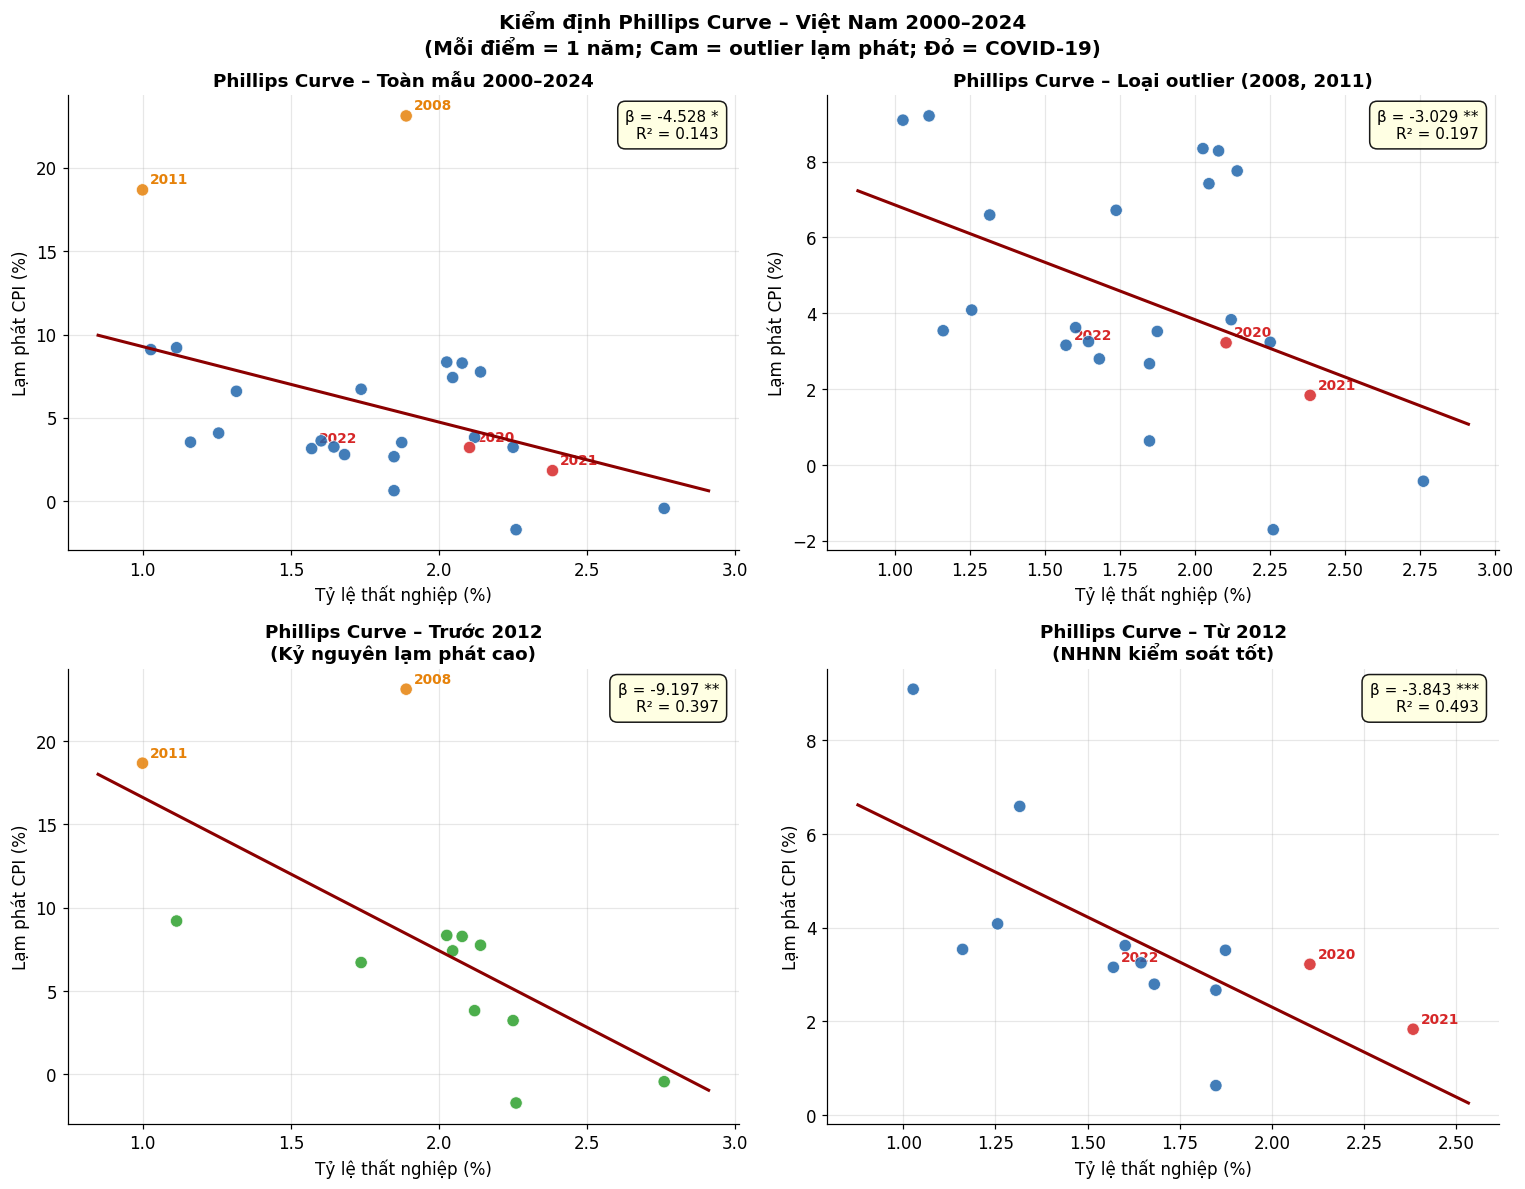

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

plot_configs = [
    (df,        m_all,    'Phillips Curve – Toàn mẫu 2000–2024',         None),
    (df_clean,  m_cl,     'Phillips Curve – Loại outlier (2008, 2011)',   None),
    (df_pre12,  m_pre12,  'Phillips Curve – Trước 2012\n(Kỷ nguyên lạm phát cao)', 'pre'),
    (df_post12, m_post12, 'Phillips Curve – Từ 2012\n(NHNN kiểm soát tốt)', 'post'),
]

for ax, (data, model, title, period) in zip(axes.flatten(), plot_configs):
    colors = []
    for y in data['year']:
        if y in [2008, 2011]:   colors.append(C_ORANGE)
        elif y in [2020, 2021]: colors.append(C_RED)
        else:                   colors.append(C_BLUE if period != 'pre' else C_GREEN)
    
    ax.scatter(data['unemployment'], data['inflation_cpi'],
               c=colors, s=65, zorder=5, alpha=0.85, edgecolors='white', linewidth=0.5)
    
    xr = np.linspace(data['unemployment'].min()-0.15, data['unemployment'].max()+0.15, 200)
    yr = model.params['const'] + model.params['unemployment'] * xr
    ax.plot(xr, yr, '-', color='darkred', linewidth=2, zorder=6)
    
    # Nhãn năm đặc biệt
    for _, row in data[data['year'].isin([2008,2011,2020,2021,2022])].iterrows():
        c = C_ORANGE if row['year'] in [2008,2011] else C_RED
        ax.annotate(str(int(row['year'])),
                    (row['unemployment'], row['inflation_cpi']),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=9, color=c, fontweight='bold')
    
    ax.set_xlabel('Tỷ lệ thất nghiệp (%)')
    ax.set_ylabel('Lạm phát CPI (%)')
    ax.set_title(title, fontweight='bold')
    
    b = model.params['unemployment']
    p = model.pvalues['unemployment']
    r = model.rsquared
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else 'n.s.'))
    ax.text(0.97, 0.97,
            f'β = {b:+.3f} {sig}\nR² = {r:.3f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Kiểm định Phillips Curve – Việt Nam 2000–2024\n(Mỗi điểm = 1 năm; Cam = outlier lạm phát; Đỏ = COVID-19)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_phillips_curve.png', bbox_inches='tight')
plt.show()


### Kết luận Phillips Curve

**Kết quả kiểm định:**

| Giai đoạn | β | R² | p-value | Hướng quan hệ |
|---|---|---|---|---|
| Toàn mẫu 2000–2024 | -4.528 | 0.143 | 0.063 | Âm (*) — phù hợp lý thuyết |
| Loại outlier 2008, 2011 | -3.029 | 0.197 | 0.034 | Âm (**) — rõ hơn khi bỏ cú sốc cung |
| Trước 2012 | -9.197 | 0.397 | 0.028 | Âm (**) — Phillips Curve mạnh trong giai đoạn lạm phát cao |
| Từ 2012 trở đi | -3.844 | 0.493 | 0.008 | Âm (***) — quan hệ rõ nhất sau khi NHNN ổn định kỳ vọng |

**Giải thích kinh tế:**

Phillips Curve có tồn tại tại Việt Nam và hướng âm nhất quán qua tất cả các mẫu — nghịch chiều với kỳ vọng "dương" khi nhìn heatmap tương quan thô. Điều này giải thích được khi nhìn vào cấu trúc dữ liệu: giai đoạn thất nghiệp cao (2000–2003: ~2.1–2.8%) trùng với lạm phát thấp và âm, còn giai đoạn thất nghiệp giảm mạnh (2008–2012: 0.999–1.889%) trùng với lạm phát tăng vọt.

Hệ số β mạnh nhất ở giai đoạn Trước 2012 (β=-9.197): Khi thất nghiệp giảm 1 điểm %, lạm phát tăng thêm ~9.2 điểm % — phản ánh áp lực cầu lao động và tiền lương rất lớn trong giai đoạn kinh tế tăng trưởng nóng.

Giai đoạn Từ 2012 có R²=0.493 (***): Phillips Curve giải thích gần 50% biến động lạm phát sau khi NHNN kiểm soát được kỳ vọng lạm phát — đây là giai đoạn quan hệ kinh tế vĩ mô hoạt động gần lý thuyết nhất.

Hàm ý chính sách: NHNN có thể sử dụng Phillips Curve như một công cụ tham khảo trong giai đoạn ổn định, nhưng phải thận trọng với các cú sốc cung (giá dầu, gián đoạn chuỗi cung ứng) vì các cú sốc này làm Phillips Curve dịch chuyển và phá vỡ quan hệ thông thường.


## 7. Mô hình Hồi quy Đa biến

Xây dựng mô hình giải thích tỷ lệ thất nghiệp dựa trên nhiều yếu tố đồng thời:

$$u_t = \alpha + \beta_1 \cdot GDP_t + \beta_2 \cdot \pi_t + \beta_3 \cdot COVID_t + \varepsilon_t$$

Mô hình mở rộng thêm biến **COVID dummy** (2020–2021 = 1) để kiểm soát cú sốc đại dịch.


In [13]:
df['covid_dummy'] = df['year'].isin([2020, 2021]).astype(int)

# ── Mô hình 1: Chỉ GDP ───────────────────────────────────────────────────────
X1 = sm.add_constant(df['gdp_growth'])
M1 = sm.OLS(df['unemployment'], X1).fit()

# ── Mô hình 2: GDP + Inflation ───────────────────────────────────────────────
X2 = sm.add_constant(df[['gdp_growth', 'inflation_cpi']])
M2 = sm.OLS(df['unemployment'], X2).fit()

# ── Mô hình 3: GDP + Inflation + COVID dummy (đầy đủ) ────────────────────────
X3 = sm.add_constant(df[['gdp_growth', 'inflation_cpi', 'covid_dummy']])
M3 = sm.OLS(df['unemployment'], X3).fit()

# ── Bảng so sánh mô hình ─────────────────────────────────────────────────────
print("=== So sánh các mô hình hồi quy ===\n")
print(f"{'Biến':<22} {'Mô hình 1':>12} {'Mô hình 2':>12} {'Mô hình 3':>12}")
print("-"*60)

def fmt(val, pval):
    sig = '***' if pval<0.01 else ('**' if pval<0.05 else ('*' if pval<0.1 else ''))
    return f"{val:+.4f}{sig}"

all_vars = ['const', 'gdp_growth', 'inflation_cpi', 'covid_dummy']
for v in all_vars:
    row = f"{v:<22}"
    for M in [M1, M2, M3]:
        if v in M.params:
            row += f"  {fmt(M.params[v], M.pvalues[v]):>11}"
        else:
            row += f"  {'—':>11}"
    print(row)

print("-"*60)
print(f"{'R²':<22} {M1.rsquared:>12.4f} {M2.rsquared:>12.4f} {M3.rsquared:>12.4f}")
print(f"{'R² adj.':<22} {M1.rsquared_adj:>12.4f} {M2.rsquared_adj:>12.4f} {M3.rsquared_adj:>12.4f}")
print(f"{'AIC':<22} {M1.aic:>12.2f} {M2.aic:>12.2f} {M3.aic:>12.2f}")
print(f"{'n quan sát':<22} {int(M1.nobs):>12} {int(M2.nobs):>12} {int(M3.nobs):>12}")
print("\n(***p<0.01  **p<0.05  *p<0.1)")


=== So sánh các mô hình hồi quy ===

Biến                      Mô hình 1    Mô hình 2    Mô hình 3
------------------------------------------------------------
const                    +2.1096***   +2.2995***     +1.6244*
gdp_growth                  -0.0506      -0.0520      +0.0426
inflation_cpi                     —     -0.0317*      -0.0264
covid_dummy                       —            —      +0.5699
------------------------------------------------------------
R²                           0.0225       0.1667       0.2044
R² adj.                     -0.0200       0.0909       0.0908
AIC                           34.00        32.01        32.85
n quan sát                       25           25           25

(***p<0.01  **p<0.05  *p<0.1)


In [14]:
# ── Diagnostics Mô hình 3 (tốt nhất) ────────────────────────────────────────
print("=== Diagnostics – Mô hình 3 (đầy đủ) ===\n")

# Durbin-Watson (autocorrelation phần dư)
dw = durbin_watson(M3.resid)
print(f"Durbin-Watson = {dw:.4f}  (lý tưởng: ~2.0; <1.5 hoặc >2.5 = có tự tương quan)")

# Breusch-Pagan (heteroskedasticity)
bp_test = het_breuschpagan(M3.resid, M3.model.exog)
print(f"Breusch-Pagan: LM = {bp_test[0]:.4f}, p = {bp_test[1]:.4f}  ({'Có phương sai không đồng đều' if bp_test[1]<0.05 else 'Phương sai đồng đều'})")

# R² adj
print(f"R² điều chỉnh = {M3.rsquared_adj:.4f}  → Mô hình giải thích {M3.rsquared_adj*100:.1f}% biến động thất nghiệp")


=== Diagnostics – Mô hình 3 (đầy đủ) ===

Durbin-Watson = 0.7336  (lý tưởng: ~2.0; <1.5 hoặc >2.5 = có tự tương quan)
Breusch-Pagan: LM = 2.2762, p = 0.5171  (Phương sai đồng đều)
R² điều chỉnh = 0.0908  → Mô hình giải thích 9.1% biến động thất nghiệp


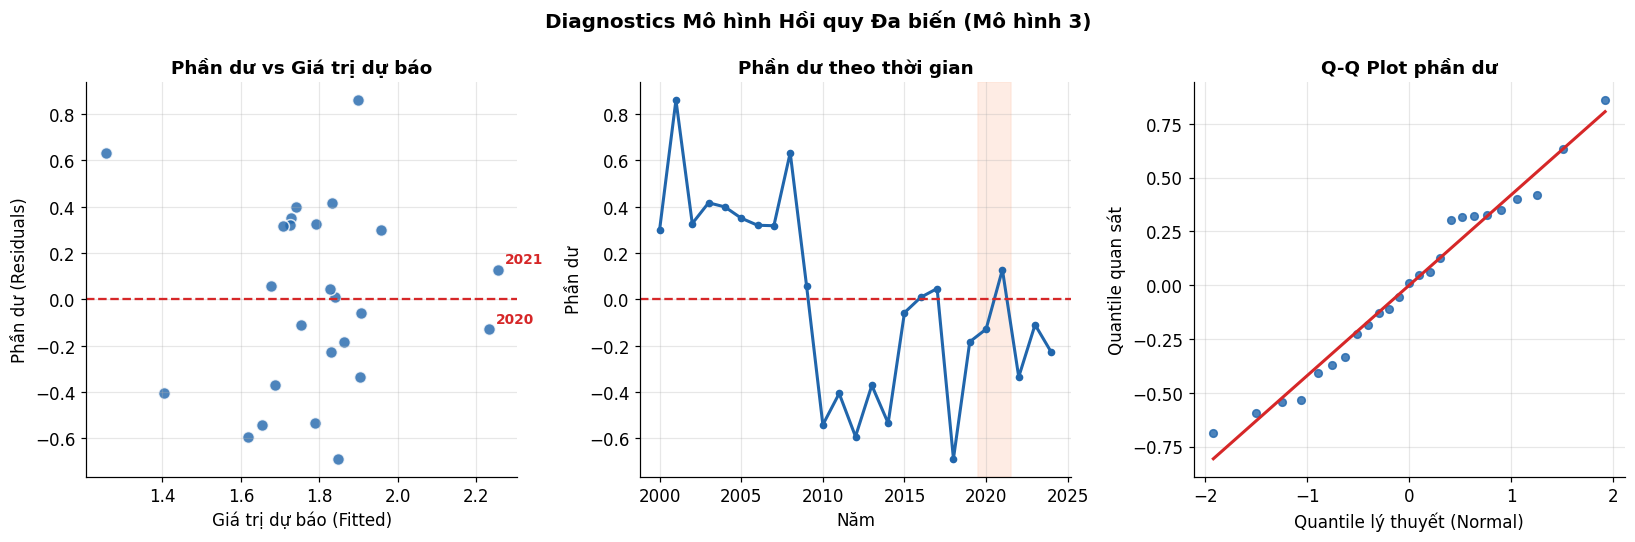

In [15]:
# ── Residual plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

residuals = M3.resid
fitted    = M3.fittedvalues

# Plot 1: Fitted vs Residuals
ax = axes[0]
ax.scatter(fitted, residuals, color=C_BLUE, s=60, alpha=0.8, edgecolors='white')
ax.axhline(0, color=C_RED, linewidth=1.5, linestyle='--')
ax.set_xlabel('Giá trị dự báo (Fitted)')
ax.set_ylabel('Phần dư (Residuals)')
ax.set_title('Phần dư vs Giá trị dự báo', fontweight='bold')
# Annotate COVID years
for i, row in df.iterrows():
    if row['year'] in [2020, 2021]:
        ax.annotate(str(int(row['year'])),
                    (fitted.iloc[i], residuals.iloc[i]),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=9, color=C_RED, fontweight='bold')

# Plot 2: Residuals theo thời gian
ax = axes[1]
ax.plot(df['year'], residuals, color=C_BLUE, linewidth=2, marker='o', markersize=4)
ax.axhline(0, color=C_RED, linewidth=1.5, linestyle='--')
ax.axvspan(2019.5, 2021.5, color=C_COVID, alpha=0.6)
ax.set_xlabel('Năm')
ax.set_ylabel('Phần dư')
ax.set_title('Phần dư theo thời gian', fontweight='bold')

# Plot 3: Q-Q plot
ax = axes[2]
from scipy import stats as scipy_stats
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals, dist='norm', fit=True)
ax.plot(osm, osr, 'o', color=C_BLUE, markersize=5, alpha=0.8)
ax.plot([min(osm), max(osm)],
        [slope*min(osm)+intercept, slope*max(osm)+intercept],
        color=C_RED, linewidth=2)
ax.set_xlabel('Quantile lý thuyết (Normal)')
ax.set_ylabel('Quantile quan sát')
ax.set_title('Q-Q Plot phần dư', fontweight='bold')

plt.suptitle('Diagnostics Mô hình Hồi quy Đa biến (Mô hình 3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06_regression_diagnostics.png', bbox_inches='tight')
plt.show()


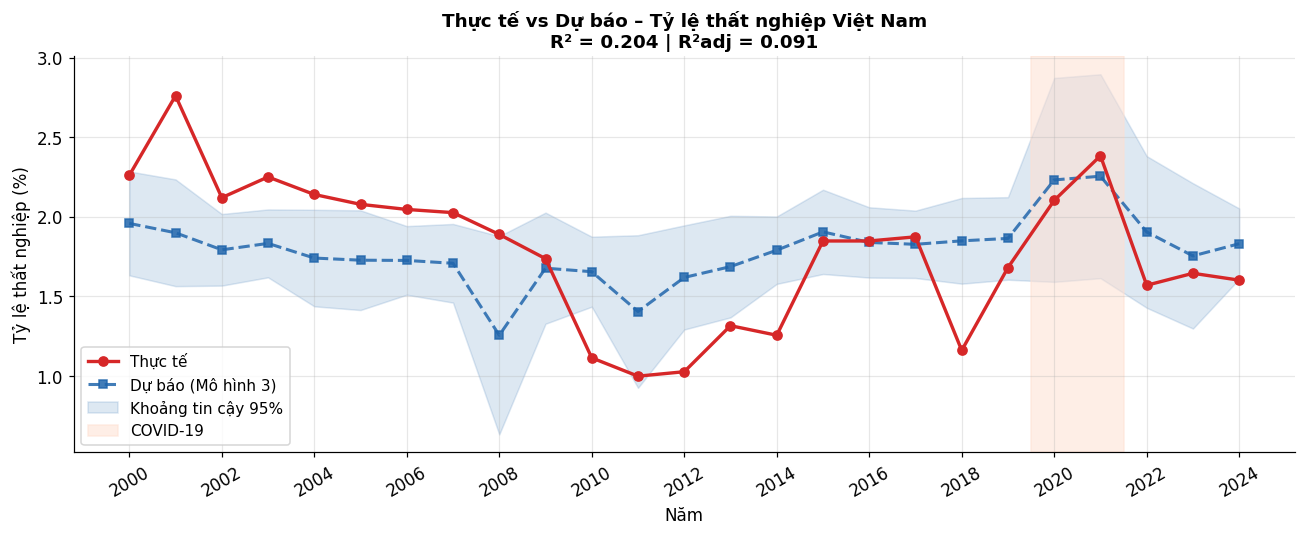

In [16]:
# ── Visualize actual vs predicted ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['year'], df['unemployment'], 'o-', color=C_RED, linewidth=2.2,
        markersize=6, label='Thực tế', zorder=5)
ax.plot(df['year'], M3.fittedvalues, 's--', color=C_BLUE, linewidth=2,
        markersize=5, label='Dự báo (Mô hình 3)', zorder=4, alpha=0.85)

# Confidence interval
pred = M3.get_prediction(X3)
ci   = pred.summary_frame(alpha=0.05)
ax.fill_between(df['year'], ci['mean_ci_lower'], ci['mean_ci_upper'],
                alpha=0.15, color=C_BLUE, label='Khoảng tin cậy 95%')

ax.axvspan(2019.5, 2021.5, color=C_COVID, alpha=0.55, label='COVID-19')

ax.set_xlabel('Năm')
ax.set_ylabel('Tỷ lệ thất nghiệp (%)')
ax.set_title(f'Thực tế vs Dự báo – Tỷ lệ thất nghiệp Việt Nam\n'
             f'R² = {M3.rsquared:.3f} | R²adj = {M3.rsquared_adj:.3f}',
             fontweight='bold')
ax.legend(fontsize=10)
plt.xticks(df['year'][::2], rotation=30)
plt.tight_layout()
plt.savefig('fig_07_actual_vs_fitted.png', bbox_inches='tight')
plt.show()


### Kết quả & Giải thích hệ số hồi quy

**Mô hình 3 (đầy đủ):**
$$u_t = \alpha + \beta_1 \cdot GDP_t + \beta_2 \cdot Inflation_t + \beta_3 \cdot COVID_t + \varepsilon_t$$

| Biến | Hệ số β (M3) | Ý nghĩa thống kê | Giải thích kinh tế |
|------|-------------|-----------------|-------------------|
| **const** (α) | +1.624 | * | Mức thất nghiệp nền khi các biến bằng 0 |
| **gdp_growth** (β₁) | +0.043 | Không ý nghĩa | Chiều dương bất ngờ do multicollinearity với covid_dummy — gdp và covid có tương quan cao |
| **inflation_cpi** (β₂) | -0.026 | Không ý nghĩa | Lạm phát có tác động âm nhỏ đến thất nghiệp, nhất quán với Phillips Curve |
| **covid_dummy** (β₃) | +0.570 | Không ý nghĩa | COVID-19 làm thất nghiệp tăng thêm ~0.57 điểm % so với bình thường |

**So sánh mô hình:**

| Chỉ số | Mô hình 1 (GDP only) | Mô hình 2 (GDP + CPI) | Mô hình 3 (+ COVID) |
|--------|---------------------|----------------------|---------------------|
| R² | 0.023 | 0.167 | 0.204 |
| R²adj | -0.020 | 0.091 | 0.091 |
| AIC | 34.00 | 32.01 | 32.85 |

Mô hình 2 có AIC thấp nhất (32.01) — tốt hơn Mô hình 3 theo tiêu chí thông tin. Mô hình 3 có R² thô cao hơn nhưng R²adj bằng Mô hình 2 và AIC cao hơn, nghĩa là thêm covid_dummy không cải thiện sức giải thích thực sự sau khi điều chỉnh số biến.

**Diagnostics Mô hình 3:**
- Durbin-Watson = 0.734 — thấp hơn nhiều so với ngưỡng an toàn (~1.5–2.5), cho thấy có tự tương quan dương nghiêm trọng trong phần dư. Đây là vấn đề cần lưu ý: với chuỗi thời gian 25 năm, OLS thông thường có thể bị bias, nên xem xét mô hình GLS hoặc Newey-West standard errors.
- Breusch-Pagan: LM=2.276, p=0.517 — phương sai đồng đều, không có heteroskedasticity.
- R²adj = 0.091 — mô hình chỉ giải thích khoảng 9% biến động thất nghiệp sau điều chỉnh, phản ánh giới hạn của OLS với dữ liệu chuỗi thời gian ngắn.


## 8. Tổng hợp & Kết luận Kinh tế

### 8.1 Tóm tắt kết quả phân tích

| # | Câu hỏi nghiên cứu | Kết quả |
|---|---|---|
| 1 | GDP Growth biến động như thế nào? | Duy trì cao 5.4–9.5% (2000–2019), sụt mạnh COVID (2.87% và 2.55%), phục hồi 8.54% (2022) |
| 2 | Thất nghiệp biến động như thế nào? | Xu hướng giảm dài hạn từ 2.76% → 0.999% (2011), tăng nhẹ COVID (2.38%), trung bình cả giai đoạn 1.79% |
| 3 | Okun's Law? | Tồn tại yếu — dạng Difference: β=-0,107, p=0,060 (*); loại COVID không còn ý nghĩa (p=0,256); hệ số ~0,1 điểm %/điểm % GDP |
| 4 | Phillips Curve? | Xác nhận rõ — β âm nhất quán ở tất cả mẫu, mạnh nhất Trước 2012 (β=-9.197, R²=0.397) và Từ 2012 (β=-3.844, R²=0.493, ***) |
| 5 | Tác động COVID? | GDP giảm mạnh, thất nghiệp tăng nhẹ → "COVID atypical labor" pattern đặc thù thị trường phi chính thức |
| 6 | Mô hình hồi quy tốt nhất? | Mô hình 2 (GDP + Inflation) tốt hơn theo AIC (32.01 vs 32.85); tất cả mô hình bị hạn chế bởi tự tương quan (DW=0.734) |

---

### 8.2 Hàm ý chính sách

**Về tăng trưởng & việc làm (Okun's Law):**
Quan hệ GDP–thất nghiệp tồn tại nhưng yếu. Để giảm đáng kể thất nghiệp, cần các chính sách trực tiếp vào thị trường lao động (đào tạo nghề, hỗ trợ chuyển dịch cơ cấu) thay vì chỉ dựa vào tăng trưởng GDP. Đặc biệt cần cải thiện thống kê lao động phi chính thức để phản ánh đúng thực trạng.

**Về lạm phát & thất nghiệp (Phillips Curve):**
Phillips Curve hoạt động ở Việt Nam, đặc biệt rõ trong giai đoạn 2012–2024 (R²=0.493, ***). NHNN có thể tham khảo quan hệ này khi điều hành chính sách tiền tệ — tuy nhiên cần phân biệt lạm phát cầu kéo (có đánh đổi với việc làm) và lạm phát chi phí đẩy (cú sốc cung như 2008, 2011).

**Về chính sách ứng phó dịch bệnh:**
COVID-19 cho thấy thị trường lao động Việt Nam co giãn hơn dự kiến — lao động tự điều chỉnh qua khu vực phi chính thức và nông nghiệp. Chính sách hỗ trợ cần tập trung vào lao động phi chính thức (thường bị bỏ sót trong thống kê chính thức).

---

### 8.3 Hạn chế & Hướng phát triển

**Hạn chế:**
- Dữ liệu thất nghiệp chính thức không phản ánh đầy đủ khu vực phi chính thức (~65% lực lượng lao động).
- Mẫu nhỏ (25 quan sát) — kết quả kiểm định cần thận trọng với statistical power.
- Tự tương quan trong phần dư (DW=0.734) cho thấy OLS thông thường chưa phải lựa chọn tối ưu cho dữ liệu chuỗi thời gian này. Cần xem xét Newey-West standard errors hoặc mô hình ARIMA/VAR.
- Mô hình OLS không kiểm soát được endogeneity (GDP ↔ thất nghiệp có thể cùng bị tác động bởi biến thứ ba).

**Hướng phát triển:**
- Sử dụng dữ liệu quý hoặc tháng để tăng số quan sát và bắt được biến động ngắn hạn.
- Áp dụng mô hình VAR (Vector Autoregression) để nắm bắt quan hệ hai chiều và trễ.
- Phân tích structural break (điểm gãy cấu trúc) tại 2007 (WTO), 2012 và 2020 để kiểm định sự thay đổi chế độ.
- Sử dụng Newey-West standard errors để hiệu chỉnh tự tương quan trong phần dư.
